In [1]:
import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
dataset_dir = "/content/drive/MyDrive/data_tanaman_herbal"

In [10]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [11]:
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 1612 images belonging to 4 classes.


In [12]:
val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 402 images belonging to 4 classes.


In [13]:
print("Jumlah data training :", train_generator.samples)
print("Jumlah data validasi :", val_generator.samples)

Jumlah data training : 1612
Jumlah data validasi : 402


In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.6)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/model_herbal_papua.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1597s 31s/step - accuracy: 0.5813 - loss: 1.0720 - val_accuracy: 0.8408 - val_loss: 0.5878 - learning_rate: 1.0000e-04
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 452s 9s/step - accuracy: 0.8226 - loss: 0.5134 - val_accuracy: 0.9328 - val_loss: 0.3398 - learning_rate: 1.0000e-04
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 466s 9s/step - accuracy: 0.9212 - loss: 0.2948 - val_accuracy: 0.9552 - val_loss: 0.2576 - learning_rate: 1.0000e-04
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 515s 9s/step - accuracy: 0.9330 - loss: 0.2264 - val_accuracy: 0.9627 - val_loss: 0.1924 - learning_rate: 1.0000e-04
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 450s 9s/step - accuracy: 0.9429 - loss: 0.1836 - val_accuracy: 0.9577 - val_loss: 0.1680 - learning_rate: 1.0000e-04
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 505s 10s/step - accuracy: 0.9628 - loss: 0.1387 - val_accuracy: 0.9677 - val_loss: 0.1379 - learning_rate: 1.0000e-04
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 441s 9s/step - accuracy: 0.96

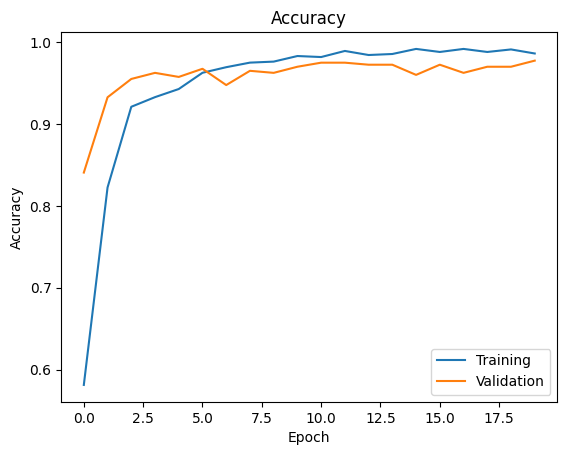

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training',
    'Validation'
])

plt.show()

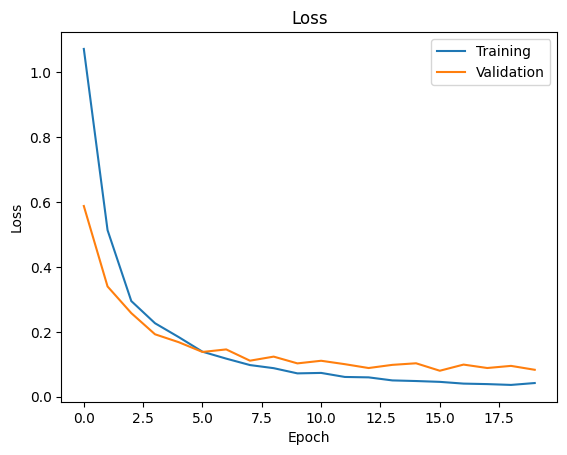

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training',
    'Validation'
])

plt.show()

In [21]:
predictions = model.predict(
    val_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 92s 7s/step


In [22]:
print(
    classification_report(
        val_generator.classes,
        y_pred,
        target_names=list(
            val_generator.class_indices.keys()
        )
    )
)

                 precision    recall  f1-score   support

daun_buah_merah       0.94      1.00      0.97       100
     daun_gatal       0.99      1.00      1.00       100
      daun_gedi       0.98      0.97      0.98       102
   sarang_semut       0.99      0.93      0.96       100

       accuracy                           0.98       402
      macro avg       0.98      0.98      0.98       402
   weighted avg       0.98      0.98      0.98       402



In [23]:
cm = confusion_matrix(
    val_generator.classes,
    y_pred
)

print(cm)

[[100   0   0   0]
 [  0 100   0   0]
 [  1   1  99   1]
 [  5   0   2  93]]


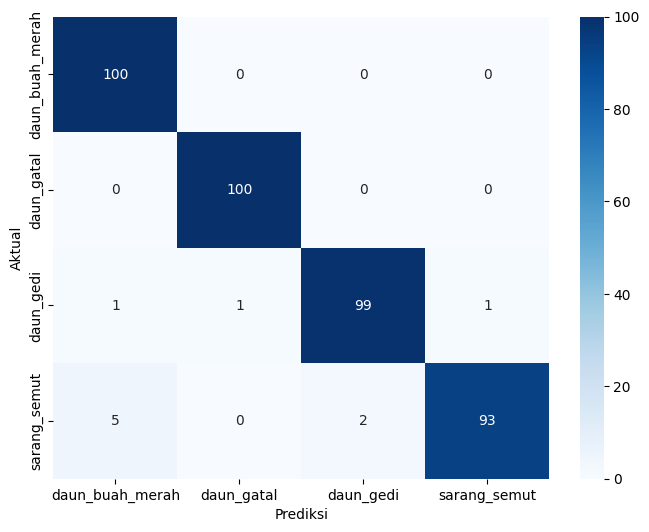

In [24]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(
        val_generator.class_indices.keys()
    ),
    yticklabels=list(
        val_generator.class_indices.keys()
    )
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

In [25]:
model.save(
    '/content/drive/MyDrive/herbal_papua_final.keras'
)

In [26]:
class_names = list(
    train_generator.class_indices.keys()
)

with open(
    '/content/drive/MyDrive/class_names.json',
    'w'
) as f:
    json.dump(
        class_names,
        f
    )

In [27]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [28]:
last_conv_layer_name = "out_relu"

In [29]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    ) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


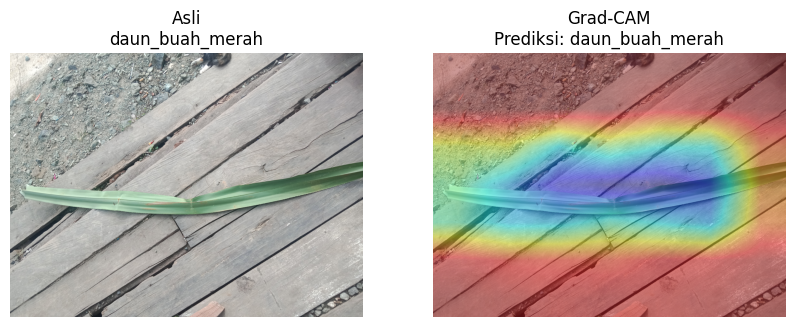

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


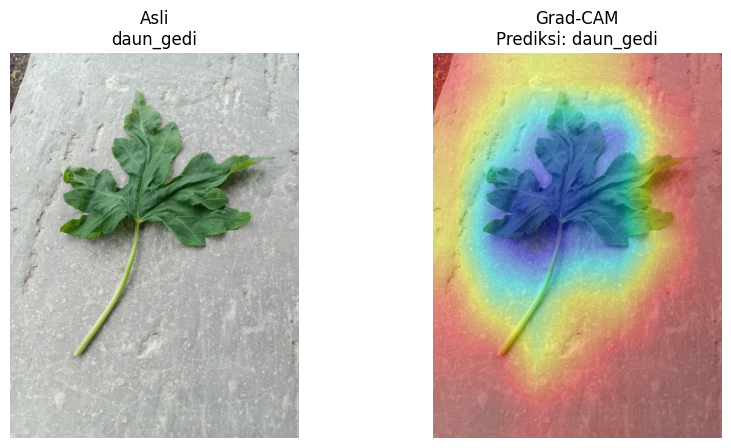

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


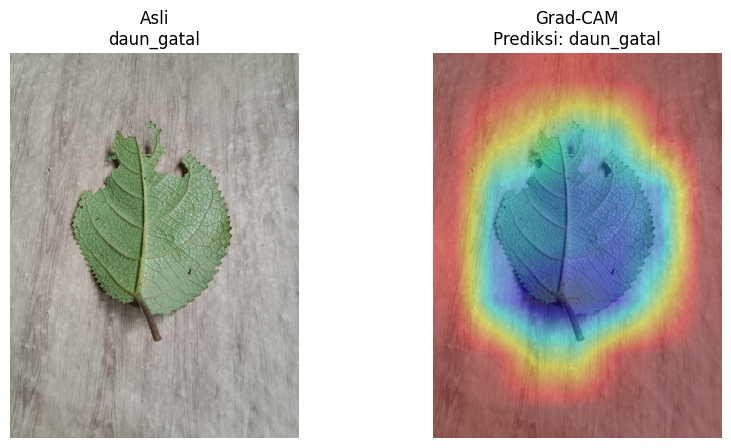

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


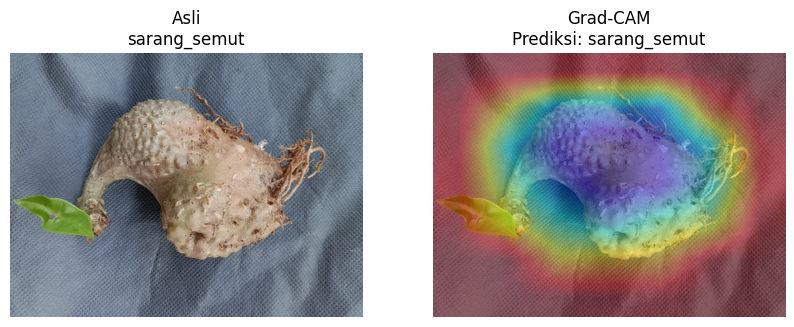

In [30]:
classes = os.listdir(dataset_dir)

for class_name in classes:

    class_path = os.path.join(
        dataset_dir,
        class_name
    )

    images = os.listdir(class_path)

    random_image = random.choice(images)

    image_path = os.path.join(
        class_path,
        random_image
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    original_img = img.copy()

    img_resized = cv2.resize(
        img,
        (224,224)
    )

    img_array = np.expand_dims(
        img_resized / 255.0,
        axis=0
    )

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    heatmap = cv2.resize(
        heatmap,
        (
            original_img.shape[1],
            original_img.shape[0]
        )
    )

    heatmap = np.uint8(
        255 * heatmap
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    superimposed_img = cv2.addWeighted(
        original_img,
        0.6,
        heatmap,
        0.4,
        0
    )

    prediction = model.predict(img_array)

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original_img)
    plt.title(
        f"Asli\n{class_name}"
    )
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(superimposed_img)
    plt.title(
        f"Grad-CAM\nPrediksi: {predicted_class}"
    )
    plt.axis("off")

    plt.show()